House Prediction Model using Random Forest and Gradient Boosting
-----

In [1]:
# Import pandas and numpy libraries

import pandas as pd
import numpy as np

In [3]:
# Read train data from csv file

train_df = pd.read_csv('Ames_train.csv')
train_df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,527402250,20,RL,NaN,12537,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,149900
1,923225240,160,RM,41.0,2665,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,127000
2,534178010,20,RL,80.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,COD,Normal,127000
3,905452160,20,RL,75.0,9525,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,128000
4,535376100,30,RL,60.0,5400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Abnorml,108480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,535478090,20,RL,70.0,7000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,2,2006,WD,Normal,105000
2340,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000
2341,531453100,60,RL,NaN,10274,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2342,905403150,20,RL,85.0,10452,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,155000


Univariatie and Bivariative Exploratory Data Analytics:
---------

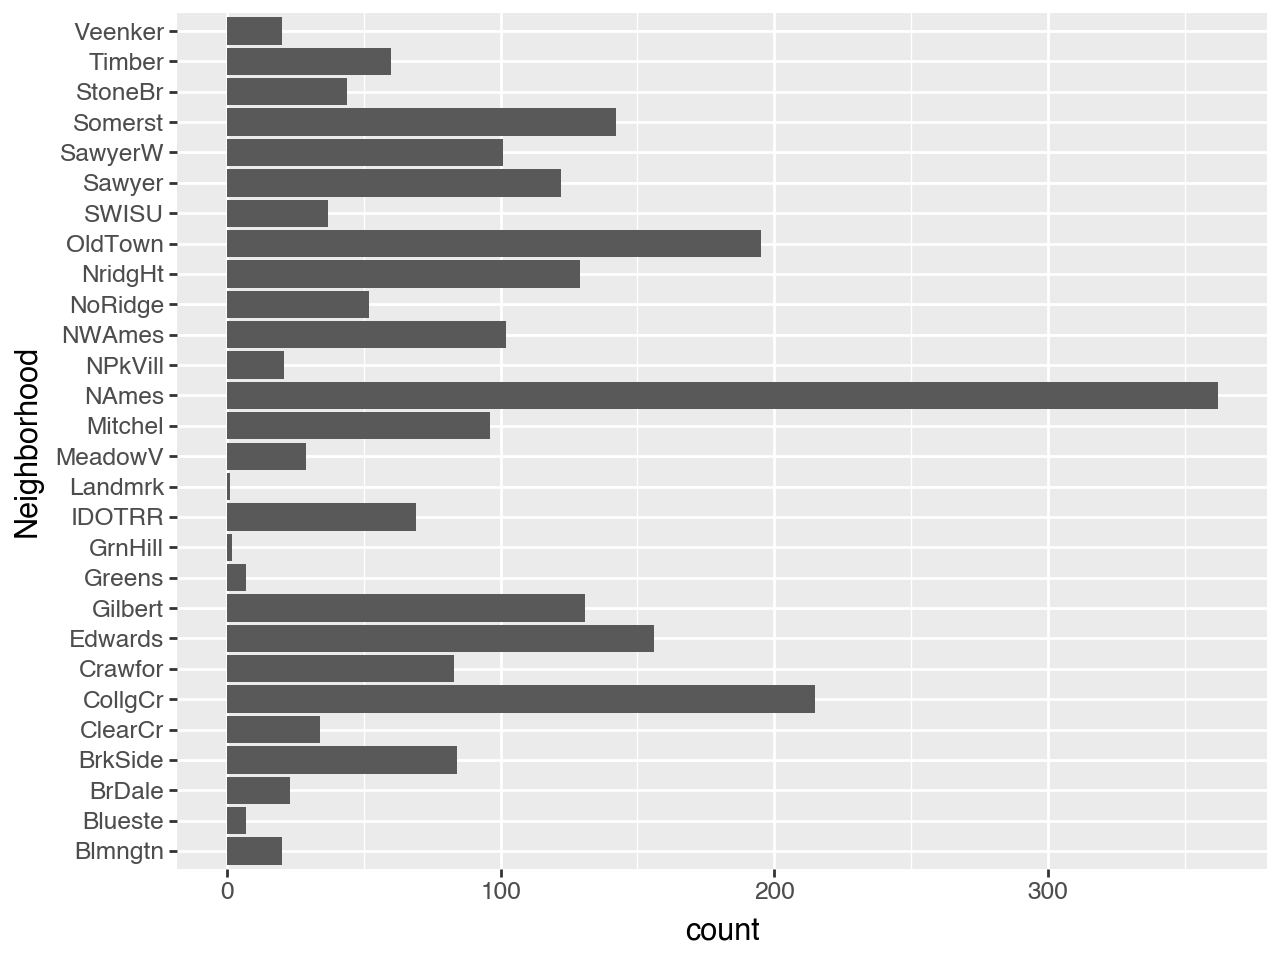

In [6]:
# Unvariative 1 : Neghborhood
# Understand the number of house in each neighborhood
# Using plotnine library to visualize the data
from plotnine import *
ggplot(aes(x = "Neighborhood"), train_df) + geom_bar() + coord_flip()

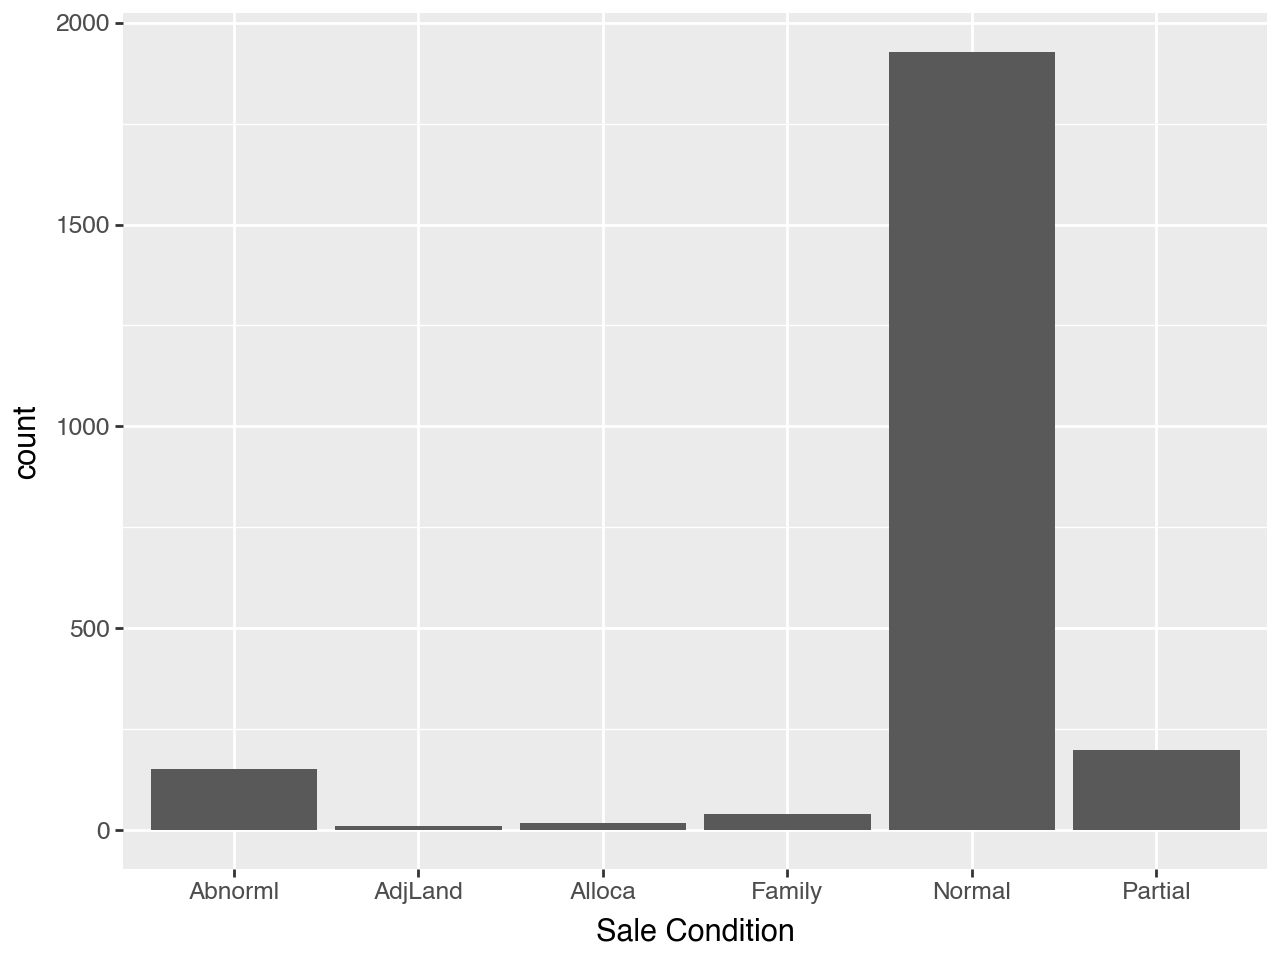

In [8]:
# Unvariative 2 : Sale Condition
# Understand the sale condition of the house
ggplot(aes(x = "Sale Condition"), train_df) + geom_bar()

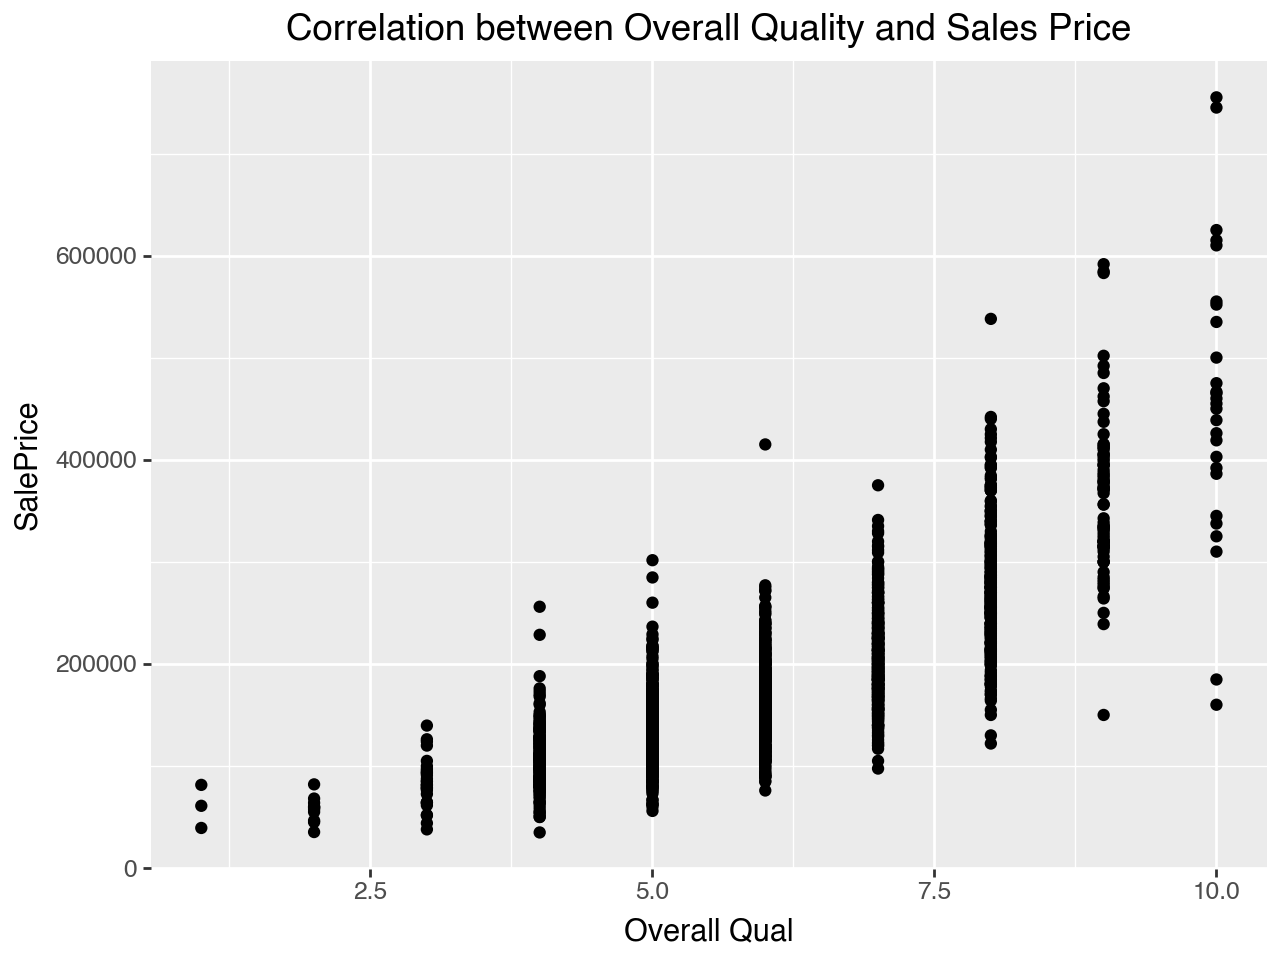

In [10]:
# Bivariative 1 : Correlation between Overall Quality and Sales Price
# We explore the correlation between Overall Quality and Sales Price
ggplot(aes(x = "Overall Qual", y = "SalePrice"), train_df) + geom_point() + ggtitle("Correlation between Overall Quality and Sales Price")

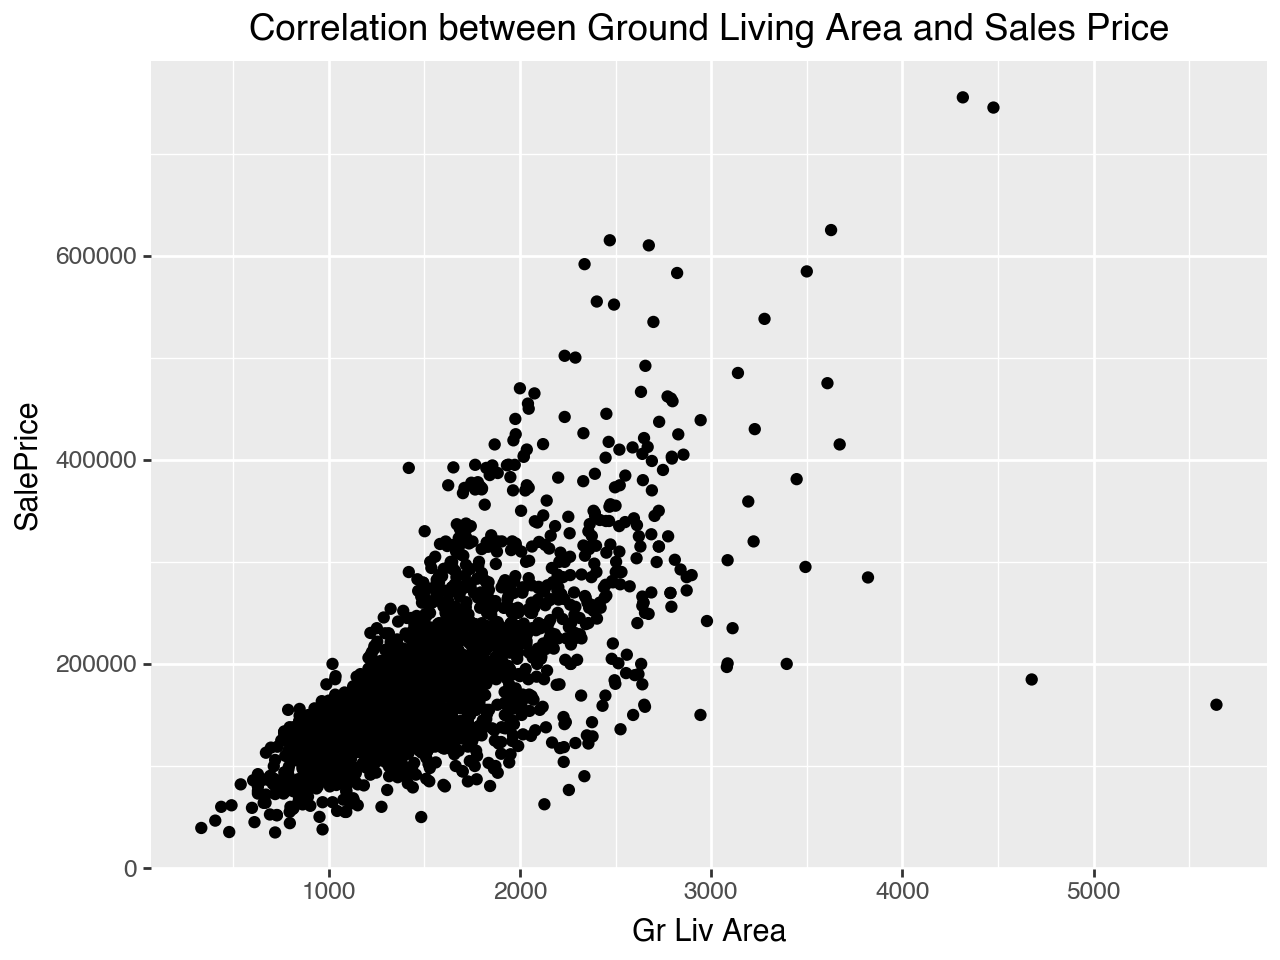

In [12]:
# Bivariative 2 : Correlation between Ground Living Area and Sales Price
# We explore the correlation between Ground Living Area and Sales Price
ggplot(aes(x = "Gr Liv Area", y = "SalePrice"), train_df) + geom_point() + ggtitle("Correlation between Ground Living Area and Sales Price")

Variable Selection: Drop Variable and Feature Engineering
---------

Variable Drop reasoning
Month Sold/Year Sold: both of these attributes are time-based and might add noise to our data
PID: This is an identifier and has no bearing on the house price

For the rest of the dropped variables, instead of deciding what to drop and what to keep, we first decided to run a basic tree. After that, we identified the essential features of our tree (feature importance>zero). We created a new data set with important features and used that to run both of our trees.

In [15]:
train_df = train_df.drop(labels=['PID', 'Mo Sold', 'Yr Sold'], axis=1)  #dropping the identifier (PID), and the months sold (Mo Sold) column as this is irrelevant for our tree while the month might capture some external influence on the house price, we decided to drop it as it might product noise in the tree (in 2017, house prices in september might be higher than in 2018) (the same goes for year sold)
train_df['MS SubClass'] = train_df['MS SubClass'].astype(str) #MSSubClass contains numerical data so it would not be captured by the code below. This variable is catagorical as the number refer to a specific type of the house and the higher number does not necceserly mean better. We used this code so that data is treated as string.

train_df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Sale Type,Sale Condition,SalePrice
0,20,RL,NaN,12537,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,0,0,NaN,NaN,NaN,0,WD,Normal,149900
1,160,RM,41.0,2665,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,0,NaN,NaN,NaN,0,WD,Normal,127000
2,20,RL,80.0,10800,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,0,NaN,NaN,NaN,0,COD,Normal,127000
3,20,RL,75.0,9525,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,0,NaN,NaN,NaN,0,WD,Normal,128000
4,30,RL,60.0,5400,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,0,NaN,NaN,NaN,0,WD,Abnorml,108480


In [17]:
from datetime import datetime

#Here we are adding the engineered variables. We define a function using def to make it easier to add them to our data set.
def add_engineered_features(train_df):

    # Total area calculation inclduing the basement
    train_df['Total_area'] = train_df['Garage Area'] + train_df['Gr Liv Area'] + train_df['Total Bsmt SF']

    #Condition and quality interaction, when we ran our initial model we noticed that the tree is might not
    #capture the interactoin between condition and quality. This feature tried to capture how
    #the interaction between quality and condition influence the price
    train_df['cond_qual_product'] = train_df['Overall Qual'] * train_df['Overall Cond']

    # Years since last renovation, this captures how long its been since the house was last renovated
    current_year = datetime.now().year  # Get the current year to make our code future proof
    train_df['Years_last_renovation'] = current_year - train_df['Year Remod/Add']

    # Total bathrooms calculation
    train_df['total_bath'] = train_df['Full Bath'] + 0.5 * train_df['Half Bath'] + train_df['Bsmt Full Bath'] + 0.5 * train_df['Bsmt Half Bath']

    return train_df

# Apply to the training data
train_df = add_engineered_features(train_df)

In [19]:
#Printing the data to make sure we have all the variables after feature engineering
train_df = train_df[ list(train_df.columns)]
train_df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Fence,Misc Feature,Misc Val,Sale Type,Sale Condition,SalePrice,Total_area,cond_qual_product,Years_last_renovation,total_bath
0,20,RL,NaN,12537,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,NaN,NaN,0,WD,Normal,149900,2656.0,30,16,2.5
1,160,RM,41.0,2665,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,WD,Normal,127000,2568.0,30,47,2.0
2,20,RL,80.0,10800,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,COD,Normal,127000,2415.0,30,61,2.0
3,20,RL,75.0,9525,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,WD,Normal,128000,2710.0,35,26,2.0
4,30,RL,60.0,5400,Pave,NaN,Reg,Lvl,AllPub,Corner,...,NaN,NaN,0,WD,Abnorml,108480,2472.0,30,56,1.0


One Hot Encoding
---------

In [22]:
from sklearn.preprocessing import OneHotEncoder

# We define our One Hot Encoder
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore')

#Here we used a code that will check if the colomn contains catigorical data.
#if it does, the variable will be added to a list that will then be used in the One Hot Encoder
#This bacially means that we dont need to manually create a list of categorical data
# we added MSSubClass to the Categorical list created as we changed its data to "string" earlier.
categorical_features = [col for col in train_df.columns if train_df[col].dtype == 'object']
print(categorical_features)

# Appling the encoding to the train dataset
feature_arr = ohe.fit_transform(train_df[categorical_features]).toarray()

# We also store the names of the categories for the new column names
feature_labels = ohe.categories_

# We apply the new feature names
features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())

# And then combine with the rest of the numerical variables
train_df = pd.concat([train_df, features], axis=1).drop(columns=categorical_features,
                                                        axis=1)

train_df.head()

['MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,NaN,12537,5,6,1971,2008,0.0,734.0,0.0,344.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,41.0,2665,5,6,1977,1977,0.0,548.0,173.0,36.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,80.0,10800,6,5,1963,1963,203.0,617.0,264.0,171.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,75.0,9525,5,7,1954,1998,0.0,954.0,0.0,218.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,60.0,5400,5,6,1921,1968,0.0,0.0,0.0,1073.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


Train and Validate
---------

Train: This is our first data set, which will be used to teach the model how to predict house prices. The model has access to the features and target values in this data set.

Validate: This dataset is used to tune hyperparameters and evaluate model performance during training. It is considered a separate dataset created by taking data from the train data set.

In [25]:
# Separating the features (input variables) from the target variabl
# X for the dataframe including all the input variables
# y for the target (saleprice) 1-column dataframe

X = train_df.drop(columns=['SalePrice']).fillna(0)

y = train_df[['SalePrice']]

# We print the shape to get a better idea of the number
# of rows and columns that we got

X.shape, y.shape

((2344, 332), (2344, 1))

In [27]:
from sklearn.model_selection import train_test_split

# Here we will split our data to train and validate.
#The train set will be used to teach our model so it can identify patterns and relationships in the data and how they interact with the target.
#The validate set will be used to evalutate our model perfomance
#The split is 70% train, and 30% validate
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.3,
                                                  random_state=232)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1640, 332), (704, 332), (1640, 1), (704, 1))

In [29]:
# The main objective here is to find the optimal hyperparameters.
# We do this by find the best combination of depth and samples in the leaf
# then train the model, and test it using logarithmic MSE (We use the log to reduce the impact of relative errors and the impact o outliers )
# in both train and validations sets:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

result_train_dict = {}
result_val_dict = {}

max_min_samples_leaf = 20
max_max_depth = 20

#Here we will run a tree of max depth and try all the different combinatoins of sample number.
# The code will repeate until it tries all the depth and leaf samples within our range
for m in range(1, max_max_depth+1, 1):
    for n in range(1, max_min_samples_leaf+1, 1):

        tree_reg = DecisionTreeRegressor(random_state=232,
                                         min_samples_leaf=n,
                                         max_depth=m)
        tree_reg.fit(X_train, y_train)

        train_predicted = tree_reg.predict(X_train)
        val_predicted = tree_reg.predict(X_val)

        result_train_dict[m, n] = mean_squared_error(np.log(y_train),
                                                     np.log(train_predicted),
                                                     squared = False)
        result_val_dict[m, n] = mean_squared_error(np.log(y_val),
                                                   np.log(val_predicted),
                                                   squared = False)

In [31]:
# We decided to skip the plotting step. We ran many trees and most of the lines were over laping instead
#we find the best combinations by looking up the minimum RMSE value in result_val_dict and finding the
#max_depth, min_samples_leaf combination that produced it
min_val_rmse = np.min(list(result_val_dict.values()))

# Find the key (max_depth, min_samples_leaf) corresponding to the minimum value
best_params = min(result_val_dict, key=result_val_dict.get)

print(f"Minimum Validation RMSE: {min_val_rmse}")
print(f"Best Parameters (max_depth, min_samples_leaf): {best_params}")

Minimum Validation RMSE: 0.16754539611970787
Best Parameters (max_depth, min_samples_leaf): (9, 10)


In [33]:
# Once the parameters has been picked, we can fit and predict both train and validation
# and double check that the error values we are getting are close.
# The RMSE for train and validat is (0.11275967964290255, 0.16754539611970787), this is expected as
# the train model is trained using a larger set and while we try to create a reprisentative set in Validate its a small sample

tree_reg = DecisionTreeRegressor(random_state=232, min_samples_leaf=10, max_depth=9)
tree_reg.fit(X_train, y_train)

train_predicted = tree_reg.predict(X_train)
val_predicted = tree_reg.predict(X_val)

(mean_squared_error(np.log(y_train), np.log(train_predicted), squared = False),
 mean_squared_error(np.log(y_val), np.log(val_predicted), squared = False))

(0.11275967964290255, 0.16754539611970787)

In [35]:
# Apply the model parameters to the whole train dataset
# getting a similar RMSE that we got for training
#The result of train RMSE is (0.11275967964290255) and the over all using the whole data set
#the RSME is (0.12058880414590203). the difference is small, therefor acceptable

tree_reg = DecisionTreeRegressor(random_state=232, min_samples_leaf=10, max_depth=9)
tree_reg.fit(X, y)

train_predicted = tree_reg.predict(X)

mean_squared_error(np.log(y), np.log(train_predicted), squared = False)

0.12058880414590203

Feature Importance
---------

In [38]:
#Here we start choosing what are the important features in our model. The code below returns
#all the features and give a number for importnace, the larger the number the more important it is
#to our tree

from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
importances = tree_reg.feature_importances_

feature_names = X_train.columns

for i in range(len(feature_names)):
    print(f"Feature: {feature_names[i]}, Importance: {importances[i]}")

Feature: Lot Frontage, Importance: 0.0011587901551875434
Feature: Lot Area, Importance: 0.004811588489962691
Feature: Overall Qual, Importance: 0.5558143275663668
Feature: Overall Cond, Importance: 0.00019786382380202472
Feature: Year Built, Importance: 0.019246724745422307
Feature: Year Remod/Add, Importance: 0.008466567064414551
Feature: Mas Vnr Area, Importance: 0.0
Feature: BsmtFin SF 1, Importance: 0.0016870308041384177
Feature: BsmtFin SF 2, Importance: 0.0
Feature: Bsmt Unf SF, Importance: 0.0049742554875353276
Feature: Total Bsmt SF, Importance: 0.0007424882127890918
Feature: 1st Flr SF, Importance: 0.0004127168890460982
Feature: 2nd Flr SF, Importance: 0.0
Feature: Low Qual Fin SF, Importance: 0.0
Feature: Gr Liv Area, Importance: 0.004028945352266811
Feature: Bsmt Full Bath, Importance: 4.857533502973637e-05
Feature: Bsmt Half Bath, Importance: 0.0
Feature: Full Bath, Importance: 0.002489191046057599
Feature: Half Bath, Importance: 0.0004497119117262301
Feature: Bedroom AbvGr

Testing
---------

Test: Completely separate from both training and validation sets. This data set is not introduced to the model during the training phase and is only used to evaluate the model's performance in the end.

In [44]:
# Read the test csv file, and repeat the process:

test_df = pd.read_csv('Ames_test.csv')
test_df = test_df.drop(labels=['PID', 'Mo Sold','Yr Sold'], axis=1)  #dropping the identifier (PID), and the months sold (Mo Sold) column as this is irrelevant for our tree while the month might capture some external influence on the house price, we decided to drop it as it might product noise in the tree (in 2017, house prices in september might be higher than in 2018)
test_df['MS SubClass'] = test_df['MS SubClass'].astype(str)#MSSubClass contains numerical data so it would not be captured by the code below. This variable is catagorical as the number refer to a specific type of the house and the higher number does not necceserly mean better. We used this code so that data is treated as string.
test_df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Sale Type,Sale Condition,SalePrice
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,120,0,NaN,MnPrv,NaN,0,WD,Normal,105000
1,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,0,NaN,NaN,NaN,0,WD,Normal,244000
2,85,RL,85.0,10625,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,0,NaN,MnPrv,NaN,0,WD,Family,170000
3,60,FV,NaN,7500,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,0,NaN,NaN,NaN,0,WD,Normal,216000
4,20,RL,70.0,10500,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,0,NaN,NaN,NaN,0,ConLI,Normal,115000


In [46]:

def add_engineered_features(test_df):

    # Total area calculation
    test_df['Total_area'] = test_df['Garage Area'] + test_df['Gr Liv Area'] + test_df['Total Bsmt SF']

    # Condition and quality interaction
    test_df['cond_qual_product'] = test_df['Overall Qual'] * test_df['Overall Cond']

    # Years since last renovation
    current_year = datetime.now().year  # Get the current year
    test_df['Years_last_renovation'] = current_year -  test_df['Year Remod/Add']


    # Total bathrooms calculation
    test_df['total_bath'] = test_df['Full Bath'] + 0.5 * test_df['Half Bath'] + test_df['Bsmt Full Bath'] + 0.5 * train_df['Bsmt Half Bath']

    return test_df

# Apply to your test data
test_df = add_engineered_features(test_df)



In [48]:
# Keep the same variables, apply the same transformations

test_df = test_df[ list(test_df.columns)]
test_df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Fence,Misc Feature,Misc Val,Sale Type,Sale Condition,SalePrice,Total_area,cond_qual_product,Years_last_renovation,total_bath
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,MnPrv,NaN,0,WD,Normal,105000,2508.0,30,63,1.0
1,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,NaN,NaN,0,WD,Normal,244000,4742.0,35,56,3.5
2,85,RL,85.0,10625,Pave,NaN,Reg,Lvl,AllPub,Inside,...,MnPrv,NaN,0,WD,Family,170000,2754.0,42,50,3.0
3,60,FV,NaN,7500,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,WD,Normal,216000,3151.0,35,24,3.5
4,20,RL,70.0,10500,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,0,ConLI,Normal,115000,1728.0,20,53,1.0


In [50]:
#We used a function that will return all the columns with dtype 'Object' and put them in a list to run
#the one hot incoder. This function will insure that all catagorical features are selected.
#We then run the one hot incoder using the new list (categorical_features) to transform catagorical features.
categorical_features = [col for col in test_df.columns if test_df[col].dtype == 'object']
print(categorical_features)

feature_arr = ohe.transform(test_df[categorical_features]).toarray()
feature_labels = ohe.categories_

features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())
test_df = pd.concat([test_df, features], axis=1).drop(columns=categorical_features,
                                                      axis=1)

test_df.head()

['MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,85.0,10625,7,6,1974,1974,81.0,885.0,168.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,NaN,7500,7,5,2000,2000,0.0,533.0,0.0,281.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,70.0,10500,4,5,1971,1971,0.0,432.0,0.0,432.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [52]:
# We keep the same set of variables

X_test= test_df.drop(columns=['SalePrice']).fillna(0)
y_test = test_df[['SalePrice']].copy()

In [54]:
# Apply the already previously trained tree to the test dataset:

y_test['SalePrice_predicted'] = tree_reg.predict(X_test)
y_test.head()

,SalePrice,SalePrice_predicted
0,105000,140334.542373
1,244000,302750.000000
2,170000,151647.949686
3,216000,191041.000000
4,115000,114604.166667


In [56]:
# The erros between test and train is acceptable as this is just for exploratoin.

print(mean_squared_error(np.log(y_test['SalePrice']),
                         np.log(y_test['SalePrice_predicted']),
                         squared = False))

0.20442316961196047


Now that we have explored the data and defined the important features we will run a code below to create a new CSV file containing the features with importance over zero only
---------

We will run the code twice: one for train and the other for test. This gives us two CSV files
---------

In [59]:
#first we need to define a new dataframe that contains the train data withought the one hot encoding
ogtrain_df = pd.read_csv('Ames_train.csv')


#we then need to add our engineered features
ogtrain_df = add_engineered_features(ogtrain_df)
ogtrain_df.head()

# We will start by creating a list of our important features
ogtrain_important_features = [
    'Overall Qual',
    'Total_area',
    'Year Built',
    'Open Porch SF',
    'Year Remod/Add',
    'cond_qual_product',
    'Years_last_renovation',
    'total_bath',
    'Bsmt Unf SF',
    'Lot Area',
    'Gr Liv Area',
    'Fireplaces',
    'BsmtFin SF 1',
    'Full Bath',
    'Lot Frontage',
    'Garage Area',
    'TotRms AbvGrd',
    'Half Bath',
    'Garage Yr Blt',
    '1st Flr SF',
    'Total Bsmt SF',
    'Enclosed Porch',
    'Overall Cond',
    'Bsmt Full Bath',
    'Bsmt Qual',
    'Kitchen Qual',
    'MS Zoning',
    'Neighborhood',
    'Bldg Type',
    'Exterior 2nd',
    'Foundation',
    'Heating QC',
    'Electrical',
    'Fireplace Qu',
    'Garage Type',
    'Garage Finish',
    'Paved Drive',
    'Sale Type',
    'SalePrice']

# Creating a new data frame to save the results
ogtrain_selected_features_df = ogtrain_df[ogtrain_important_features]

# We will now pull the data frame as a CSV file
file_path = 'ogtrain_selected_features.csv'  # loaction of the CSV in the drive
ogtrain_selected_features_df.to_csv(file_path, index=False)  # index=False because we dont need this column containing the index

In [61]:
print(ogtrain_important_features)

['Overall Qual', 'Total_area', 'Year Built', 'Open Porch SF', 'Year Remod/Add', 'cond_qual_product', 'Years_last_renovation', 'total_bath', 'Bsmt Unf SF', 'Lot Area', 'Gr Liv Area', 'Fireplaces', 'BsmtFin SF 1', 'Full Bath', 'Lot Frontage', 'Garage Area', 'TotRms AbvGrd', 'Half Bath', 'Garage Yr Blt', '1st Flr SF', 'Total Bsmt SF', 'Enclosed Porch', 'Overall Cond', 'Bsmt Full Bath', 'Bsmt Qual', 'Kitchen Qual', 'MS Zoning', 'Neighborhood', 'Bldg Type', 'Exterior 2nd', 'Foundation', 'Heating QC', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type', 'SalePrice']


In [63]:
#first we need to define a new dataframe that contains the train data withought the one hot encoding
ogtest_df = pd.read_csv('Ames_test.csv')

#we then need to add our engineered features
ogtest_df = add_engineered_features(ogtest_df)
ogtest_df.head()

# We will start by creating a list of our important features
ogtest_important_features = [
    'Overall Qual',
    'Total_area',
    'Year Built',
    'Open Porch SF',
    'Year Remod/Add',
    'cond_qual_product',
    'Years_last_renovation',
    'total_bath',
    'Bsmt Unf SF',
    'Lot Area',
    'Gr Liv Area',
    'Fireplaces',
    'BsmtFin SF 1',
    'Full Bath',
    'Lot Frontage',
    'Garage Area',
    'TotRms AbvGrd',
    'Half Bath',
    'Garage Yr Blt',
    '1st Flr SF',
    'Total Bsmt SF',
    'Enclosed Porch',
    'Overall Cond',
    'Bsmt Full Bath',
    'Bsmt Qual',
    'Kitchen Qual',
    'MS Zoning',
    'Neighborhood',
    'Bldg Type',
    'Exterior 2nd',
    'Foundation',
    'Heating QC',
    'Electrical',
    'Fireplace Qu',
    'Garage Type',
    'Garage Finish',
    'Paved Drive',
    'Sale Type',
    'SalePrice']


# Creating a new data frame to save the results
ogtest_selected_features_df = ogtest_df[ogtest_important_features]

# We will now pull the data frame as a CSV file
file_path = 'ogtest_selected_features.csv'  # loaction of the CSV in the drive
ogtest_selected_features_df.to_csv(file_path, index=False)  # index=False because we dont need this column


In [65]:
print(ogtest_important_features)

['Overall Qual', 'Total_area', 'Year Built', 'Open Porch SF', 'Year Remod/Add', 'cond_qual_product', 'Years_last_renovation', 'total_bath', 'Bsmt Unf SF', 'Lot Area', 'Gr Liv Area', 'Fireplaces', 'BsmtFin SF 1', 'Full Bath', 'Lot Frontage', 'Garage Area', 'TotRms AbvGrd', 'Half Bath', 'Garage Yr Blt', '1st Flr SF', 'Total Bsmt SF', 'Enclosed Porch', 'Overall Cond', 'Bsmt Full Bath', 'Bsmt Qual', 'Kitchen Qual', 'MS Zoning', 'Neighborhood', 'Bldg Type', 'Exterior 2nd', 'Foundation', 'Heating QC', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type', 'SalePrice']


Random Forest Algorithm
-----

Based on the explanation above, we repeat the same process starts from One Hot Encoding, Train, Validation, and Test. Now, in this Random Forest algorithm we use the new dataset based on feature importance.

In [68]:
# Read train data from csv file. Here we use the new CSV file containing only the variables
#that we identified as important

train_rf_df = pd.read_csv('ogtrain_selected_features.csv')

train_rf_df.head()

,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Exterior 2nd,Foundation,Heating QC,Electrical,Fireplace Qu,Garage Type,Garage Finish,Paved Drive,Sale Type,SalePrice
0,5,2656.0,1971,0,2008,30,16,2.5,344.0,12537,...,VinylSd,CBlock,Ex,SBrkr,Fa,Attchd,Fin,Y,WD,149900
1,5,2568.0,1977,26,1977,30,47,2.0,36.0,2665,...,CmentBd,PConc,Ex,SBrkr,TA,Attchd,RFn,Y,WD,127000
2,6,2415.0,1963,133,1963,30,61,2.0,171.0,10800,...,HdBoard,CBlock,TA,SBrkr,NaN,Attchd,Fin,Y,COD,127000
3,5,2710.0,1954,0,1998,35,26,2.0,218.0,9525,...,Wd Shng,CBlock,TA,SBrkr,NaN,Attchd,Fin,Y,WD,128000
4,5,2472.0,1921,0,1968,30,56,1.0,1073.0,5400,...,MetalSd,BrkTil,Ex,SBrkr,NaN,Detchd,Unf,Y,WD,108480


In [70]:
# For the example codes, I will only use
# 4 variables and the target price
train_rf_df = train_rf_df[ list(train_rf_df.columns)]

train_rf_df.head()

,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Exterior 2nd,Foundation,Heating QC,Electrical,Fireplace Qu,Garage Type,Garage Finish,Paved Drive,Sale Type,SalePrice
0,5,2656.0,1971,0,2008,30,16,2.5,344.0,12537,...,VinylSd,CBlock,Ex,SBrkr,Fa,Attchd,Fin,Y,WD,149900
1,5,2568.0,1977,26,1977,30,47,2.0,36.0,2665,...,CmentBd,PConc,Ex,SBrkr,TA,Attchd,RFn,Y,WD,127000
2,6,2415.0,1963,133,1963,30,61,2.0,171.0,10800,...,HdBoard,CBlock,TA,SBrkr,NaN,Attchd,Fin,Y,COD,127000
3,5,2710.0,1954,0,1998,35,26,2.0,218.0,9525,...,Wd Shng,CBlock,TA,SBrkr,NaN,Attchd,Fin,Y,WD,128000
4,5,2472.0,1921,0,1968,30,56,1.0,1073.0,5400,...,MetalSd,BrkTil,Ex,SBrkr,NaN,Detchd,Unf,Y,WD,108480


In [72]:
from sklearn.preprocessing import OneHotEncoder

#here we run one hot incoder similar to the one we used in the explore tree before
# We define our One Hot Encoder
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore')

categorical_features = [col for col in train_rf_df.columns if train_rf_df[col].dtype == 'object']
print(categorical_features)

# We apply the encoding to our train dataset
feature_arr = ohe.fit_transform(train_rf_df[categorical_features]).toarray()

# We also store the names of the categories for the new column names
feature_labels = ohe.categories_

# Applying the new feature names
features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())

# And then combine with the rest of the numerical variables
train_rf_df = pd.concat([train_rf_df, features], axis=1).drop(columns=categorical_features,
                                                        axis=1)

train_rf_df.head()

['Bsmt Qual', 'Kitchen Qual', 'MS Zoning', 'Neighborhood', 'Bldg Type', 'Exterior 2nd', 'Foundation', 'Heating QC', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type']


,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Sale Type_COD,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,5,2656.0,1971,0,2008,30,16,2.5,344.0,12537,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5,2568.0,1977,26,1977,30,47,2.0,36.0,2665,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,6,2415.0,1963,133,1963,30,61,2.0,171.0,10800,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,2710.0,1954,0,1998,35,26,2.0,218.0,9525,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,2472.0,1921,0,1968,30,56,1.0,1073.0,5400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [74]:
# Separating the features (input variables) from the target variabl
# X for the dataframe including all the input variables
# y for the target (saleprice) 1-column dataframe

X = train_rf_df.drop(columns=['SalePrice']).fillna(0)

y = train_rf_df[['SalePrice']]

# We print the shape to get a better idea of the number
# of rows and columns that we got

X.shape, y.shape

((2344, 138), (2344, 1))

In [76]:
from sklearn.model_selection import train_test_split

# Here we will split our data to train and validate.
#The train set will be used to teach our model so it can identify patterns and relationships in the data and how they interact with the target.
#The validate set will be used to evalutate our model perfomance
#The split is 70% train, and 30% validate

X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.3,
                                                  random_state=232)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1640, 138), (704, 138), (1640, 1), (704, 1))

In [78]:
# We'll iterate through different number of estimators,features, and max_depth.
# train the model and test it using RMSE
# in both train and validations sets:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

result_train_dict = {}
result_val_dict = {}

#The max estimators and depth used by our tree
max_max_depth = 20
max_n_estimators = 20

for m in range(1, max_max_depth, 2): #

    print(m)

    for n in range(1, max_n_estimators, 2): # number of trees
        for s in [0.6, 0.7, 0.8, 0.9]:      # % of samples
            for k in [0.6, 0.7, 0.8, 0.9]:  # % of features

                tree_reg = RandomForestRegressor(random_state= 232,
                                                 n_estimators= n,
                                                 max_depth= m,
                                                 max_features= k,
                                                 bootstrap= True,
                                                 max_samples= s)

                tree_reg.fit(X_train, np.ravel(y_train))

                train_predicted = tree_reg.predict(X_train)
                val_predicted = tree_reg.predict(X_val)

                result_train_dict[m, n, s, k] = mean_squared_error(np.log(y_train),
                                                                   np.log(train_predicted),
                                                                   squared = False)
                result_val_dict[m, n, s, k] = mean_squared_error(np.log(y_val),
                                                                 np.log(val_predicted),
                                                                 squared = False)

1
3
5
7
9
11
13
15
17
19


In [82]:
#We create a new dataframe and sort is based on the val_rmse column.
#this isentially creates a list that shows the different combos of hyperperameters and their
#error score

pd.DataFrame.from_dict(result_val_dict,
                       orient='index',
                       columns=['val_rmse']
                      ).sort_values(by='val_rmse',
                                    ascending=True)

,val_rmse
"(13, 19, 0.6, 0.6)",0.134122
"(11, 15, 0.7, 0.7)",0.134201
"(11, 13, 0.7, 0.7)",0.134455
"(13, 17, 0.6, 0.6)",0.134564
"(19, 15, 0.9, 0.6)",0.134653
...,...
"(1, 1, 0.9, 0.6)",0.319688
"(1, 1, 0.9, 0.7)",0.319688
"(1, 1, 0.9, 0.8)",0.319688
"(1, 3, 0.9, 0.7)",0.321418


In [84]:
#This is an extra step, while we have the hyperparameters sorted above we can also use this code
#to return the best hyperparameter that have the lowest RMSE
# Convert the result_val_dict to a DataFrame
results_df = pd.DataFrame.from_dict(result_val_dict, orient='index', columns=['val_rmse'])

# Sort by validation RMSE (ascending order)
results_df = results_df.sort_values(by='val_rmse', ascending=True)

# Get the best hyperparameters (from the index of the first row)
best_hyperparameters = results_df.index[0]

print("Best Hyperparameters:", best_hyperparameters)

Best Hyperparameters: (13, 19, 0.6, 0.6)


In [86]:
#This code returns the train_rmse given our selected hyperparameters

pd.DataFrame.from_dict(result_train_dict, orient='index',
                       columns=['train_rmse']).loc[[(13, 19, 0.6, 0.6)]]

,train_rmse
"(13, 19, 0.6, 0.6)",0.082567


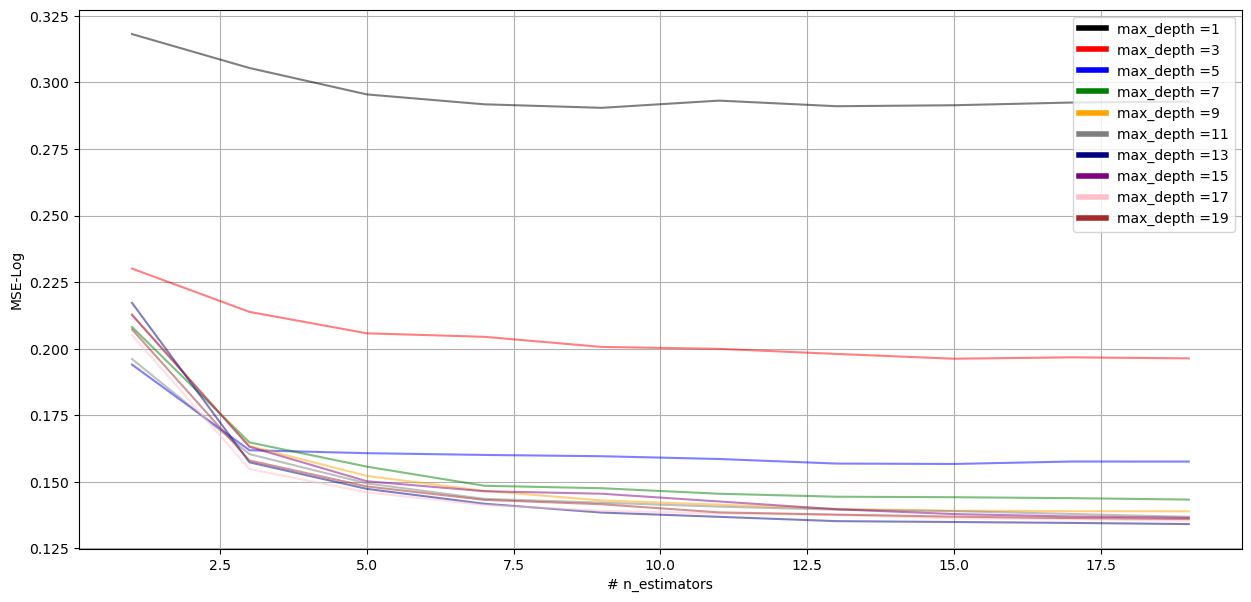

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(15, 7))
# Increased the number of colors to accomodate all max_depth values.
colors = ['black', 'red', 'blue', 'green', 'orange', 'gray', 'navy', 'purple', 'pink', 'brown']
color_index = 0
custom_lines = np.array([])
custom_names = np.array([])

s = 0.6
k = 0.6

for m in range(1, max_max_depth, 2):

    line_plot_train = []
    line_plot_val = []

    for n in range(1, max_n_estimators, 2):
        line_plot_train.append(result_train_dict.get((m, n, s, k)))
        line_plot_val.append(result_val_dict.get((m, n, s, k)))

    # Un-comment this line for plotting train error evolution
    # plt.plot(np.arange(start=1, stop=max_n_estimators, step=2),
    #          line_plot_train, alpha=0.5, c=colors[color_index], linestyle='--')

    # Un-comment this line for plotting validation error evolution
    plt.plot(np.arange(start=1, stop=max_n_estimators, step=2),
             line_plot_val, alpha=0.5, c=colors[color_index])

    color_line = Line2D([0], [0], color=colors[color_index], lw=4)
    custom_lines = np.append(custom_lines, color_line)
    color_name = 'max_depth =' + str(m)
    custom_names = np.append(custom_names, color_name)
    color_index += 1

# ax.set_xlim(max_min_samples_leaf, 0)
# plt.xticks(np.arange(start=1, stop=max_min_samples_leaf, step=2), rotation=90, size=10)

ax.grid(True)
plt.xlabel('# n_estimators')
plt.ylabel('MSE-Log')

ax.legend(custom_lines, custom_names)

plt.show()

In [90]:
# We have chosen n_estimators=19, max_depth=13, and 60% of both features and samples

tree_reg = RandomForestRegressor(random_state=232,
                                 n_estimators= 19,
                                 max_depth= 13,
                                 max_features= 0.6,
                                 max_samples= 0.6,
                                 bootstrap= True)

tree_reg.fit(X_train, np.ravel(y_train))

train_predicted = tree_reg.predict(X_train)
val_predicted = tree_reg.predict(X_val)

(mean_squared_error(np.log(y_train), np.log(train_predicted), squared = False),
 mean_squared_error(np.log(y_val), np.log(val_predicted), squared = False))

(0.08256660674274151, 0.13412214146203036)

In [92]:
# Apply the model parameters to the whole train dataset
# The train RMSE value is 0.08256660674274151 and the overall Train (using the full train dataframe) RMSE value is 0.08063669997078235
# We can see a minor differece between both values with overall Train (using the full train dataframe) RMSE being lower.
# This is mainly attributed to the sample size train RMSE is based on 70% of the data while overall train uses the entire dataframe

tree_reg = RandomForestRegressor(random_state=232,
                                 n_estimators= 19,
                                 max_depth= 13,
                                 max_features= 0.6,
                                 max_samples= 0.6,
                                 bootstrap= True)

tree_reg.fit(X, np.ravel(y))

train_predicted = tree_reg.predict(X)

mean_squared_error(np.log(y), np.log(train_predicted), squared = False)

0.08063669997078235

In [94]:
# Read the test csv file, and repeat the process:

test_rf_df = pd.read_csv('ogtest_selected_features.csv')
test_rf_df.head()

,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Exterior 2nd,Foundation,Heating QC,Electrical,Fireplace Qu,Garage Type,Garage Finish,Paved Drive,Sale Type,SalePrice
0,5,2508.0,1961,0,1961,30,63,1.0,270.0,11622,...,VinylSd,CBlock,TA,SBrkr,NaN,Attchd,Unf,Y,WD,105000
1,7,4742.0,1968,0,1968,35,56,3.5,1045.0,11160,...,BrkFace,CBlock,Ex,SBrkr,TA,Attchd,Fin,Y,WD,244000
2,7,2754.0,1974,120,1974,42,50,3.0,0.0,10625,...,Plywood,CBlock,TA,SBrkr,TA,Attchd,RFn,Y,WD,170000
3,7,3151.0,2000,96,2000,35,24,3.5,281.0,7500,...,VinylSd,PConc,Ex,SBrkr,NaN,Attchd,RFn,Y,WD,216000
4,4,1728.0,1971,0,1971,20,53,1.0,432.0,10500,...,HdBoard,CBlock,TA,SBrkr,Po,NaN,NaN,Y,ConLI,115000


In [96]:
# Keep the same variables, apply the same transformations

test_rf_df = test_rf_df[list(test_rf_df.columns)]

test_rf_df.head()

,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Exterior 2nd,Foundation,Heating QC,Electrical,Fireplace Qu,Garage Type,Garage Finish,Paved Drive,Sale Type,SalePrice
0,5,2508.0,1961,0,1961,30,63,1.0,270.0,11622,...,VinylSd,CBlock,TA,SBrkr,NaN,Attchd,Unf,Y,WD,105000
1,7,4742.0,1968,0,1968,35,56,3.5,1045.0,11160,...,BrkFace,CBlock,Ex,SBrkr,TA,Attchd,Fin,Y,WD,244000
2,7,2754.0,1974,120,1974,42,50,3.0,0.0,10625,...,Plywood,CBlock,TA,SBrkr,TA,Attchd,RFn,Y,WD,170000
3,7,3151.0,2000,96,2000,35,24,3.5,281.0,7500,...,VinylSd,PConc,Ex,SBrkr,NaN,Attchd,RFn,Y,WD,216000
4,4,1728.0,1971,0,1971,20,53,1.0,432.0,10500,...,HdBoard,CBlock,TA,SBrkr,Po,NaN,NaN,Y,ConLI,115000


In [98]:
# Applying the one hot incoder without "fit"

categorical_features = [col for col in test_rf_df.columns if test_rf_df[col].dtype == 'object']
print(categorical_features)

feature_arr = ohe.transform(test_rf_df[categorical_features]).toarray()
feature_labels = ohe.categories_

features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())
test_rf_df = pd.concat([test_rf_df, features], axis=1).drop(columns=categorical_features,
                                                      axis=1)

test_rf_df.head()

['Bsmt Qual', 'Kitchen Qual', 'MS Zoning', 'Neighborhood', 'Bldg Type', 'Exterior 2nd', 'Foundation', 'Heating QC', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type']


,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Sale Type_COD,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,5,2508.0,1961,0,1961,30,63,1.0,270.0,11622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,7,4742.0,1968,0,1968,35,56,3.5,1045.0,11160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7,2754.0,1974,120,1974,42,50,3.0,0.0,10625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7,3151.0,2000,96,2000,35,24,3.5,281.0,7500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,1728.0,1971,0,1971,20,53,1.0,432.0,10500,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [100]:
# Here we create two data frames. 1) has only the target 2)has all variables except for the target
# we do this to evaluate our models performance on unseen data. We predict the price and then compare it to the target

X_test= test_rf_df.drop(columns=['SalePrice']).fillna(0)

y_test = test_rf_df[['SalePrice']].copy()
print (X_test.shape, y_test.shape)

(586, 138) (586, 1)


In [102]:
# Apply the already previously trained tree to our test dataset:

y_test['SalePrice_predicted'] = tree_reg.predict(X_test)
y_test.head()

,SalePrice,SalePrice_predicted
0,105000,133854.693087
1,244000,246805.263158
2,170000,169831.540702
3,216000,207304.450382
4,115000,103666.541353


In [104]:
# What error are we getting for the test set?

print(mean_squared_error(np.log(y_test['SalePrice']),
                         np.log(y_test['SalePrice_predicted']),
                         squared = False))

0.17110707942796446


Gradient Boosting Algorithm
-----

Based on the explanation above, we repeat the same process starts from One Hot Encoding, Train, Validation, and Test. Now, in this Gradient Boosting algorithm we use the new dataset based on feature importance.

In [108]:
# Read train data from csv file

train_df = pd.read_csv('ogtrain_selected_features.csv')
train_df.head()

,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Exterior 2nd,Foundation,Heating QC,Electrical,Fireplace Qu,Garage Type,Garage Finish,Paved Drive,Sale Type,SalePrice
0,5,2656.0,1971,0,2008,30,16,2.5,344.0,12537,...,VinylSd,CBlock,Ex,SBrkr,Fa,Attchd,Fin,Y,WD,149900
1,5,2568.0,1977,26,1977,30,47,2.0,36.0,2665,...,CmentBd,PConc,Ex,SBrkr,TA,Attchd,RFn,Y,WD,127000
2,6,2415.0,1963,133,1963,30,61,2.0,171.0,10800,...,HdBoard,CBlock,TA,SBrkr,NaN,Attchd,Fin,Y,COD,127000
3,5,2710.0,1954,0,1998,35,26,2.0,218.0,9525,...,Wd Shng,CBlock,TA,SBrkr,NaN,Attchd,Fin,Y,WD,128000
4,5,2472.0,1921,0,1968,30,56,1.0,1073.0,5400,...,MetalSd,BrkTil,Ex,SBrkr,NaN,Detchd,Unf,Y,WD,108480


In [110]:
from sklearn.preprocessing import OneHotEncoder

# We define our One Hot Encoder
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore')

#Here we used a code that will check if the colomn contains catigorical data.
#if it does, the variable will be added to a list that will then be used in the One Hot Encoder
#This bacially means that we dont need to manually create a list of categorical data
categorical_features = [col for col in train_df.columns if train_df[col].dtype == 'object']
print(categorical_features)

# Appling the encoding to the train dataset
feature_arr = ohe.fit_transform(train_df[categorical_features]).toarray()

# We also store the names of the categories for the new column names
feature_labels = ohe.categories_

# We apply the new one hot encoder names
features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())

# And then combine with the rest of the numerical variables
train_df = pd.concat([train_df, features], axis=1).drop(columns=categorical_features,
                                                        axis=1)

train_df.head()

['Bsmt Qual', 'Kitchen Qual', 'MS Zoning', 'Neighborhood', 'Bldg Type', 'Exterior 2nd', 'Foundation', 'Heating QC', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type']


,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Sale Type_COD,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,5,2656.0,1971,0,2008,30,16,2.5,344.0,12537,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5,2568.0,1977,26,1977,30,47,2.0,36.0,2665,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,6,2415.0,1963,133,1963,30,61,2.0,171.0,10800,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,2710.0,1954,0,1998,35,26,2.0,218.0,9525,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,2472.0,1921,0,1968,30,56,1.0,1073.0,5400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [112]:
# X for the dataframe including all the input variables
X = train_df.drop(columns=['SalePrice']).fillna(0)             

# y for the target variable which is SalePrice
y = train_df[['SalePrice']]

# We print the shape to get a better idea of the number 
# of rows and columns that we got
X.shape, y.shape

((2344, 138), (2344, 1))

In [114]:
# We use sklearn library to conduct training and validation
from sklearn.model_selection import train_test_split

# As seen before, we need to create a random split for validation
# in this case, we'll use a 30% split.

X_train, X_val, y_train, y_val = train_test_split(X, 
                                                  y, 
                                                  test_size=0.3, 
                                                  random_state=232)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1640, 138), (704, 138), (1640, 1), (704, 1))

In [116]:
# We use sklearn library run gradient boosting algorithm and calculate the MSE
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error


result_train_dict = {} # We create an array to store the train result
result_val_dict = {} # We create an array to store the validation result
error_curve_train_dict = {} # We create an array to store the error train result
error_curve_val_dict = {} # We create an array to store the error train result

for d in [15,20,25]: # max_tree_depth, we set maximum depth of decision tree of 15, 20, 25 because we have more variables and we want to capture more patterns
    for lr in [0.1, 0.05, 0.01]: # learning rate, we set the weight high, medium, low to find optimal learning rate on our tree
        for f in [0.3, 0.5, 0.7]: # % of features (columns) to be used for training
            for s in [0.5, 0.6, 0.7]: # % of data (rows) to be used for training
                for ms in [20, 40, 60]: # we increase the min_samples required to split because we have more dataset than the example

                    #Initialize the gradient boosing algorithm and we didn't change anything
                    gb_reg = GradientBoostingRegressor(random_state= 232, 
                                                       n_estimators= 1000,
                                                       validation_fraction= 0.1,
                                                       n_iter_no_change= 20,
                                                       verbose=0,
                                                       max_depth= d,
                                                       learning_rate= lr,
                                                       max_features= f,
                                                       subsample= s,
                                                       min_samples_split= ms)

                    # We transform the X train and y train to an array
                    gb_reg.fit(X_train, np.ravel(y_train))

                    # After training, we will do prediction on training and validation
                    train_predicted = gb_reg.predict(X_train)
                    val_predicted = gb_reg.predict(X_val)

                    # We will evaluate the model by calculating the RMSE
                    result_train_dict[d, lr, f, s, ms] = mean_squared_error(
                        np.log(y_train), 
                        np.log(train_predicted), 
                        squared = False)
                    result_val_dict[d, lr, f, s, ms] = mean_squared_error(
                        np.log(y_val), 
                        np.log(val_predicted), 
                        squared = False)

                    # We store the result to this variable, in order to do visualization
                    error_curve_train_dict[d, lr, f, s, ms] = gb_reg.train_score_

In [118]:
# Sort the validation result from smallest to highest. This will make us easier to choose the gradient boosting parameter
pd.DataFrame.from_dict(result_val_dict, orient='index', columns=['val_rmse']
                      ).sort_values(by='val_rmse', ascending=True)

,val_rmse
"(20, 0.01, 0.5, 0.6, 60)",0.122875
"(25, 0.01, 0.7, 0.5, 60)",0.123135
"(20, 0.01, 0.5, 0.5, 40)",0.123234
"(20, 0.01, 0.7, 0.5, 40)",0.123318
"(25, 0.01, 0.7, 0.6, 60)",0.123692
...,...
"(20, 0.1, 0.7, 0.7, 20)",0.132266
"(20, 0.1, 0.5, 0.7, 60)",0.132589
"(25, 0.1, 0.3, 0.7, 20)",0.132807
"(15, 0.1, 0.5, 0.7, 20)",0.132818


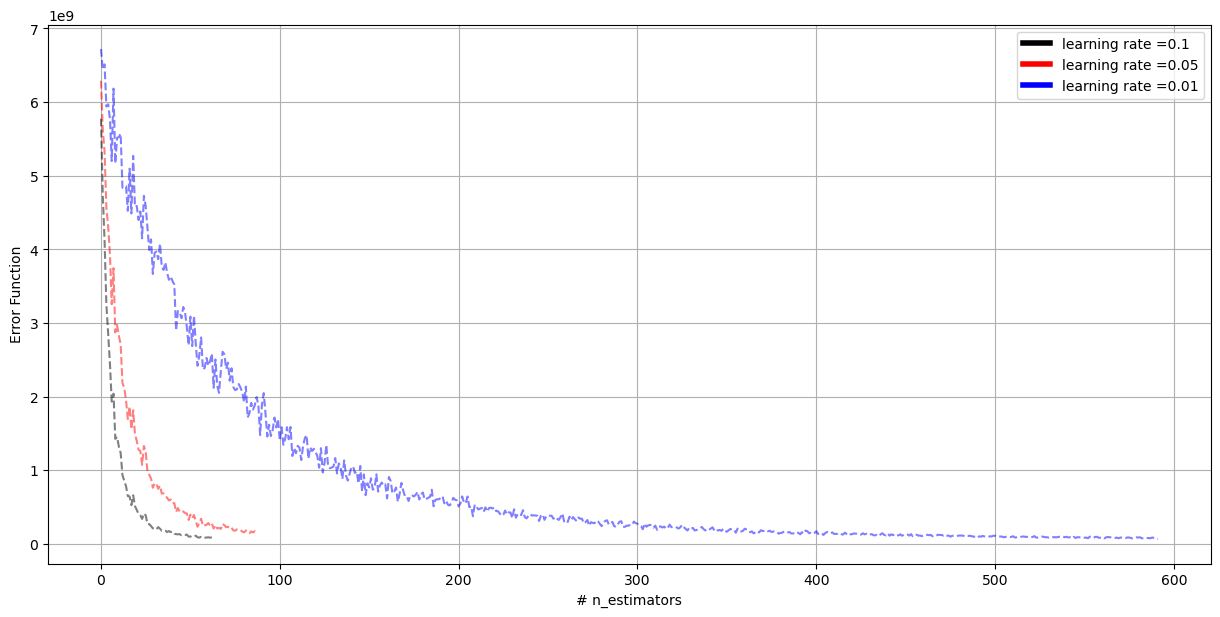

In [120]:
# Import matplotlib for data visualization
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# These are the visual of graph such as figure size, line color, and naming
fig, ax = plt.subplots(figsize=(15, 7))
colors= ['black', 'red', 'blue']
color_index = 0
custom_lines = np.array([])
custom_names = np.array([])

# We choose the lowest validation error to plot
d = 20
f = 0.5
s = 0.6
ms = 60

# We use the learning rate define in previous blocks
for lr in [0.1, 0.05, 0.01]:

    # Plot the dictionary
    plt.plot(error_curve_train_dict[d, lr, f, s, ms], 
             alpha=0.5, c=colors[color_index], linestyle='--')
    # Color indexing
    color_line = Line2D([0], [0], color=colors[color_index], lw=4)
    custom_lines = np.append(custom_lines,color_line)
    color_name = 'learning rate =' + str(lr)
    custom_names = np.append(custom_names,color_name)
    color_index+=1
# Define x array with n_estimator and y with the error result
ax.grid(True)
plt.xlabel('# n_estimators')
plt.ylabel('Error Function')

ax.legend(custom_lines, custom_names)

plt.show()

In [122]:
# Select the parameter 10, 0.1, 0.5, 0.7, 40 to find train RMSE value quickly
pd.DataFrame.from_dict(result_train_dict, orient='index', 
                       columns=['train_rmse']).loc[[(20, 0.01, 0.5, 0.6, 60)]]

,train_rmse
"(20, 0.01, 0.5, 0.6, 60)",0.060825


In [124]:
# Apply the model parameters to the whole train dataset
# Getting a similar RMSE that we got for training
# We adjust the paramaeter based on the result above
best = GradientBoostingRegressor(random_state= 232, 
                                 n_estimators= 1000,
                                 validation_fraction= 0.1,
                                 n_iter_no_change= 20,
                                 verbose=0,
                                 max_depth= 20,
                                 learning_rate= 0.01,
                                 max_features= 0.5,
                                 subsample= 0.6,
                                 min_samples_split= 60)

best.fit(X.fillna(0), np.ravel(y))

# We run prediction of target value of dataset and fill the missing value with 0
train_predicted = best.predict(X.fillna(0))
# RMSE calculation
mean_squared_error(np.log(y), np.log(train_predicted), squared = False)

0.07010074341951786

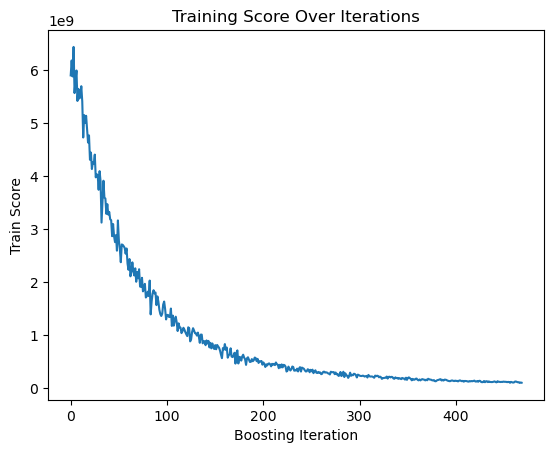

In [138]:
# Plot the train score
plt.plot(best.train_score_)
plt.title("Training Score Over Iterations")
plt.xlabel("Boosting Iteration")
plt.ylabel("Train Score")
plt.show()

In [140]:
# Read the test csv file for test data

test_df = pd.read_csv('ogtest_selected_features.csv')
test_df.head()

,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Exterior 2nd,Foundation,Heating QC,Electrical,Fireplace Qu,Garage Type,Garage Finish,Paved Drive,Sale Type,SalePrice
0,5,2508.0,1961,0,1961,30,63,1.0,270.0,11622,...,VinylSd,CBlock,TA,SBrkr,NaN,Attchd,Unf,Y,WD,105000
1,7,4742.0,1968,0,1968,35,56,3.5,1045.0,11160,...,BrkFace,CBlock,Ex,SBrkr,TA,Attchd,Fin,Y,WD,244000
2,7,2754.0,1974,120,1974,42,50,3.0,0.0,10625,...,Plywood,CBlock,TA,SBrkr,TA,Attchd,RFn,Y,WD,170000
3,7,3151.0,2000,96,2000,35,24,3.5,281.0,7500,...,VinylSd,PConc,Ex,SBrkr,NaN,Attchd,RFn,Y,WD,216000
4,4,1728.0,1971,0,1971,20,53,1.0,432.0,10500,...,HdBoard,CBlock,TA,SBrkr,Po,NaN,NaN,Y,ConLI,115000


In [142]:
#Here we used a code that will check if the colomn contains catigorical data.
#if it does, the variable will be added to a list that will then be used in the One Hot Encoder
#This bacially means that we dont need to manually create a list of categorical data
categorical_features = [col for col in test_df.columns if test_df[col].dtype == 'object']
print(categorical_features)

# Appling the encoding to the train dataset
feature_arr = ohe.transform(test_df[categorical_features]).toarray()

# We also store the names of the categories for the new column names
feature_labels = ohe.categories_

# We apply the new feature names
features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())

# And then combine with the rest of the numerical variables
test_df = pd.concat([test_df, features], axis=1).drop(columns=categorical_features,
                                                        axis=1)

test_df.head()

['Bsmt Qual', 'Kitchen Qual', 'MS Zoning', 'Neighborhood', 'Bldg Type', 'Exterior 2nd', 'Foundation', 'Heating QC', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type']


,Overall Qual,Total_area,Year Built,Open Porch SF,Year Remod/Add,cond_qual_product,Years_last_renovation,total_bath,Bsmt Unf SF,Lot Area,...,Sale Type_COD,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,5,2508.0,1961,0,1961,30,63,1.0,270.0,11622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,7,4742.0,1968,0,1968,35,56,3.5,1045.0,11160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7,2754.0,1974,120,1974,42,50,3.0,0.0,10625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7,3151.0,2000,96,2000,35,24,3.5,281.0,7500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,1728.0,1971,0,1971,20,53,1.0,432.0,10500,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [144]:
# We split the variable into x_test and the target into y_test
X_test= test_df.drop(columns=['SalePrice']).fillna(0)
y_test = test_df[['SalePrice']].copy()

In [146]:
# Apply the already previously trained tree to our test dataset:
y_test['SalePrice_predicted'] = best.predict(X_test.fillna(0))
y_test.head()

,SalePrice,SalePrice_predicted
0,105000,133756.489762
1,244000,228804.324543
2,170000,174191.324268
3,216000,209584.801264
4,115000,96102.704944


In [148]:
# This explain the error that we get after running the test
print(mean_squared_error(np.log(y_test['SalePrice']), 
                         np.log(y_test['SalePrice_predicted']), 
                         squared = False))

0.15586493235266743


Result
-----

Random Forest Train RMSE: 0.08063669997078235

Random Forest Test RMSE: 0.17110707942796446

Random Forest top 5 important features: Total_area, Overall Qual, Garage Area Bsmt Qual_Ex, cond_qual_product

Gradient Boosting Train RMSE: 0.07010074341951786

Gradient Boosting Test RMSE: 0.15586493235266743

Gradient Boosting top 5 important features:  Total_area , Overall Qual, Bsmt Qual_Ex, Gr Liv Area ,cond_qual_product


Conclusion
-----
Based on the explanation in class, Gradient Boosting perform better than Random Forest. Here, the code that we run also prove the same result where Gradient Boosing error is lower than Random Forest.